In [1]:
import os
repo = 'boston-marathons'
counter = 0
max_depth = 50
current = os.getcwd()
while True:
    current_tmp = os.path.basename(os.getcwd())
    if current_tmp == repo:
        print(f"Main dir found: {os.getcwd()}")
        break
    else:
        os.chdir("..")
        counter += 1
        if counter >= max_depth:
            print(f"Reached {max_depth} levels up — '{repo}' not found.")
            os.chdir(current)
            print(f"Current path: {current}")
            break

Main dir found: D:\Scripts\Data Science\projekty\repo\boston-marathons


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math as math
from scripts.mappings import continent_colors

In [3]:
df = pd.read_csv('./data/clean/boston_features.csv')
df.head()

,Name,M/F,Age,Age Group,Country,Continent,City,Pace,5K,10K,15K,20K,25K,30K,35K,40K,Official Time,Year,Place_Year,Place_Global
0,"Desisa, Lelisa",M,25,22–25,ETH,Africa,Ambo,3.065431,0.245278,0.495278,0.749167,1.008056,1.268611,1.533333,1.799722,2.044167,2.154722,2015,1,1
1,"Kirui, Geoffrey",M,24,22–25,KEN,Africa,Keringet,3.075787,0.256944,0.507778,0.762222,1.020833,1.283056,1.550278,1.805278,2.048056,2.160278,2017,1,2
2,"Tsegay, Yemane Adhane",M,30,30–33,ETH,Africa,Addis Ababa,3.086144,0.245278,0.495278,0.749444,1.007778,1.268611,1.533056,1.799722,2.045000,2.163333,2015,2,3
3,"Rupp, Galen",M,30,30–33,USA,North America,Portland,3.086144,0.256667,0.507500,0.762222,1.020833,1.283056,1.550278,1.805278,2.053889,2.166111,2017,2,4
4,"Chebet, Wilson",M,29,26–29,KEN,Africa,Marakwet,3.096500,0.245278,0.495278,0.749167,1.008056,1.268611,1.533333,1.799722,2.050278,2.172778,2015,3,5


In [4]:
plt.style.use('seaborn-v0_8-whitegrid')

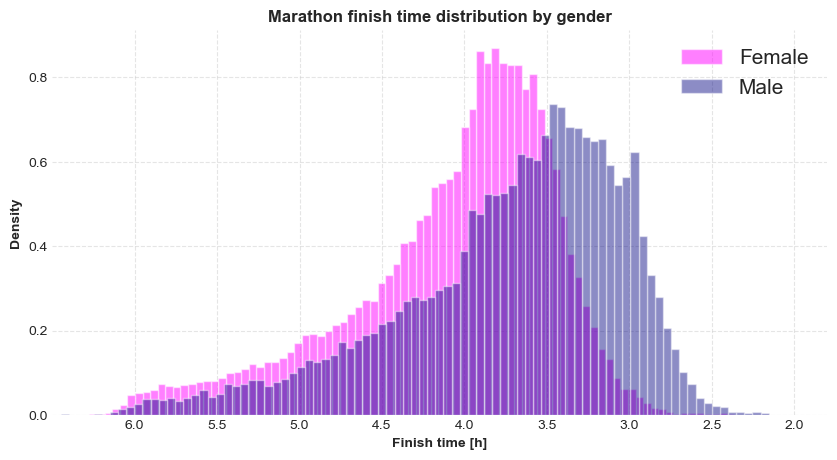

In [5]:
fix, ax = plt.subplots(figsize=(10,5))

# data
subset = df[['Official Time', 'M/F']]
subset_m = subset[subset['M/F'] == 'M']
subset_f = subset[subset['M/F'] == 'F']
# create
ax.hist(subset_f['Official Time'], bins='fd', density=True, color='magenta', edgecolor='white', alpha=0.5, label='Female')
ax.hist(subset_m['Official Time'], bins='fd', density=True, color='navy', edgecolor='white', alpha=0.45, label='Male')

## xy settings
# x
ax.set_xlabel('Finish time [h]', weight='bold')
ax.set_xlim(1.8,6.5)
ax.set_xticks(np.arange(2,6.1,0.5))
ax.invert_xaxis()
# y
ax.set_ylabel('Density', weight='bold')

## style
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_title('Marathon finish time distribution by gender', weight='bold')
ax.spines[['top','bottom','left','right']].set_visible(False)
ax.legend(fontsize=15)

plt.savefig('charts/hist_finishtime_gender.png', dpi=300, bbox_inches='tight')
plt.show()